# 02 - Feature Engineering

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load dataset
file_path = '../data/raw/hotel_bookings.csv'
df = pd.read_csv(file_path)
# Feature creation
df['stay_duration'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']

In [2]:
# Encode categorical variables
label_encoders = {}
for col in ['meal', 'market_segment', 'assigned_room_type']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Save processed data
df.to_csv('../data/processed/hotel_bookings_processed.csv', index=False)

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,stay_duration,total_guests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,2.0


In [11]:
# Check for missing values
print("Missing values before handling:")
print(df.isnull().sum())

# Fill missing values for numeric columns with the median
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill missing values for non-numeric columns with the mode (most frequent value)
non_numeric_cols = df.select_dtypes(exclude=['number']).columns
for col in non_numeric_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify that there are no missing values
print("Missing values after handling:")
print(df.isnull().sum())

Missing values before handling:
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                   

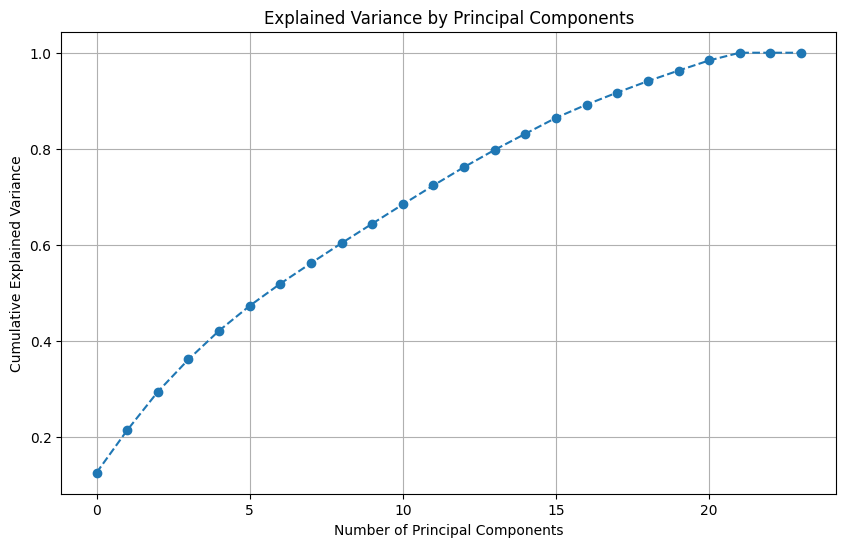

Feature importance for the first principal component:
                                Importance
stay_duration                     0.464431
stays_in_week_nights              0.422787
stays_in_weekend_nights           0.381484
total_guests                      0.342307
adults                            0.283197
market_segment                    0.224308
children                          0.193803
assigned_room_type                0.193702
agent                             0.180371
total_of_special_requests         0.149820
lead_time                         0.102815
arrival_date_year                 0.070115
booking_changes                   0.065067
babies                            0.061503
company                           0.050735
meal                              0.040546
required_car_parking_spaces       0.013123
is_canceled                       0.008979
arrival_date_week_number          0.008796
arrival_date_day_of_month        -0.010497
days_in_waiting_list             -0.038218


In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Select numerical features for PCA
numerical_features = df.select_dtypes(include=[np.number]).drop(columns=['adr'])

# Handle missing values by filling with the median
numerical_features.fillna(numerical_features.median(), inplace=True)

X = numerical_features.values

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

# Display feature importance for the first principal component
feature_importance = pd.DataFrame(
    pca.components_[0],
    index=numerical_features.columns,
    columns=['Importance']
).sort_values(by='Importance', ascending=False)
print("Feature importance for the first principal component:")
print(feature_importance)

# 03 - Model Training

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Load processed data
df = pd.read_csv('../data/processed/hotel_bookings_processed.csv')

In [ ]:
# Define features and target
features = ['lead_time', 'stay_duration', 'total_guests', 'meal', 'market_segment', 'assigned_room_type', 'booking_changes']
target = 'adr'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Take square root manually
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}')


MAE: 22.49, RMSE: 35.40, R2: 0.45


In [ ]:
# Save model
joblib.dump(model, '../models/hotel_price_model.pkl')

['../models/hotel_price_model.pkl']

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

import matplotlib.pyplot as plt

# Select numerical features for PCA
numerical_features = df.select_dtypes(include=[np.number]).drop(columns=['adr'])
X = numerical_features.values

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

# Display feature importance for the first principal component
feature_importance = pd.DataFrame(
    pca.components_[0], 
    index=numerical_features.columns, 
    columns=['Importance']
).sort_values(by='Importance', ascending=False)
print("Feature importance for the first principal component:")
print(feature_importance)

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values